# Sanity Check — all_v2_region_fixed.csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
original = pd.read_csv('../data/raw/all_v2.csv')
fixed = pd.read_csv('../data/processed/all_v2_region_fixed.csv')

print('Оригинал:', original.shape)
print('Исправленный:', fixed.shape)

Оригинал: (5477006, 13)
Исправленный: (5474552, 13)


## 1. Количество строк

In [3]:
removed = len(original) - len(fixed)
print(f'Оригинал:    {len(original):,}')
print(f'Исправленный:{len(fixed):,}')
print(f'Удалено:     {removed:,} (морские точки)')

Оригинал:    5,477,006
Исправленный:5,474,552
Удалено:     2,454 (морские точки)


## 2. Пропуски и типы данных

In [4]:
print('Пропуски:')
print(fixed.isnull().sum())
print()
print('Типы данных:')
print(fixed.dtypes)

Пропуски:
price            0
date             0
time             0
geo_lat          0
geo_lon          0
building_type    0
level            0
levels           0
rooms            0
area             0
kitchen_area     0
object_type      0
region           0
dtype: int64

Типы данных:
price              int64
date                 str
time                 str
geo_lat          float64
geo_lon          float64
building_type      int64
level              int64
levels             int64
rooms              int64
area             float64
kitchen_area     float64
object_type        int64
region           float64
dtype: object


## 3. Регионы

In [5]:
print(f'Уникальных регионов: {fixed["region"].nunique()}')
print(f'Мин/макс: {fixed["region"].min():.0f} / {fixed["region"].max():.0f}')
print(f'Крым (91):       {(fixed["region"] == 91).sum():,}')
print(f'Севастополь (92):{(fixed["region"] == 92).sum():,}')
print(f'NaN регионов:    {fixed["region"].isna().sum()}')

Уникальных регионов: 84
Мин/макс: 1 / 92
Крым (91):       4,677
Севастополь (92):2,226
NaN регионов:    0


## 4. Распределение ключевых признаков

In [6]:
cols = ['price', 'area', 'kitchen_area', 'level', 'levels', 'rooms']
display(pd.DataFrame({
    'Оригинал': original[cols].describe().loc['mean'],
    'Исправленный': fixed[cols].describe().loc['mean']
}).round(2))

,Оригинал,Исправленный
price,4422029.02,4420197.07
area,53.92,53.92
kitchen_area,10.63,10.63
level,6.21,6.21
levels,11.40,11.40
rooms,1.73,1.73


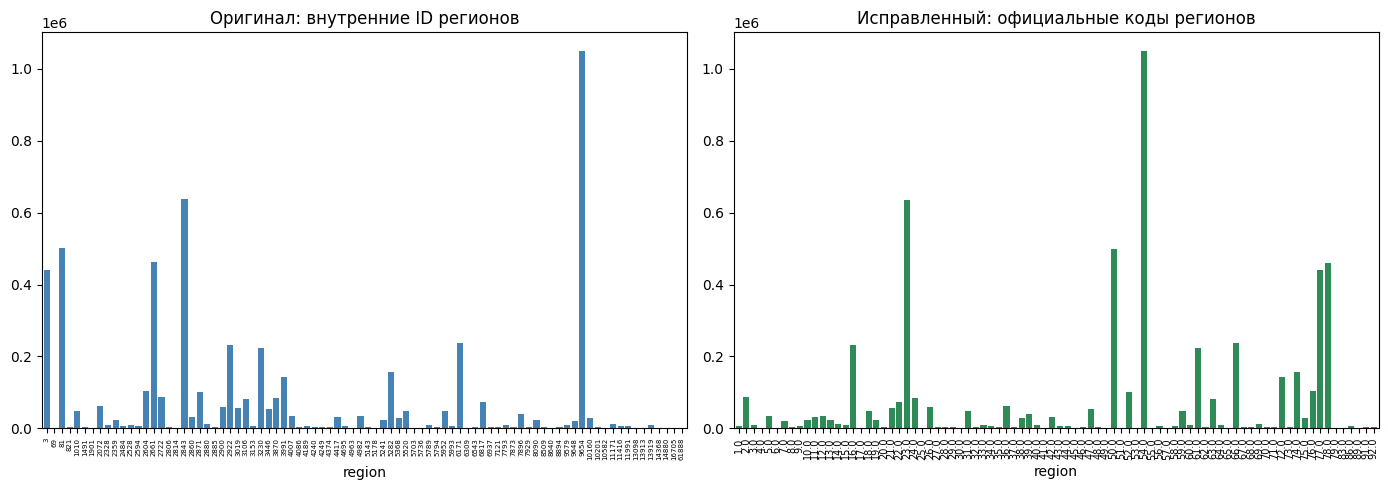

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

original['region'].value_counts().sort_index().plot(
    ax=axes[0], kind='bar', width=0.8, color='steelblue')
axes[0].set_title('Оригинал: внутренние ID регионов')
axes[0].tick_params(axis='x', labelsize=5)

fixed['region'].value_counts().sort_index().plot(
    ax=axes[1], kind='bar', width=0.8, color='seagreen')
axes[1].set_title('Исправленный: официальные коды регионов')
axes[1].tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.show()

## 5. Итог

In [8]:
checks = {
    'Строк не потеряно (кроме морских)': removed < 10000,
    'Нет NaN в регионах': fixed['region'].isna().sum() == 0,
    'Нет NaN в цене': fixed['price'].isna().sum() == 0,
    'Нет NaN в координатах': fixed[['geo_lat','geo_lon']].isna().sum().sum() == 0,
    'Крым присутствует': (fixed['region'] == 91).sum() > 0,
}

for check, result in checks.items():
    status = 'OK' if result else 'ОШИБКА'
    print(f'[{status}] {check}')

[OK] Строк не потеряно (кроме морских)
[OK] Нет NaN в регионах
[OK] Нет NaN в цене
[OK] Нет NaN в координатах
[OK] Крым присутствует
